In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import xarray as xr
import statistics as st

import functools as ft

import scipy as sc
from scipy.stats import norm

import cartopy.crs as ccrs
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import xarray as xr
import statistics as st

import functools as ft

import scipy as sc
from scipy.stats import norm

import cartopy.crs as ccrs

In [18]:
path_name = './data/mslp.mon.mean.nc' 
ds = xr.open_dataset(path_name, decode_timedelta=True)

stockholm = ds.sel(lat=57.5, lon=17.5,  method='nearest').mslp



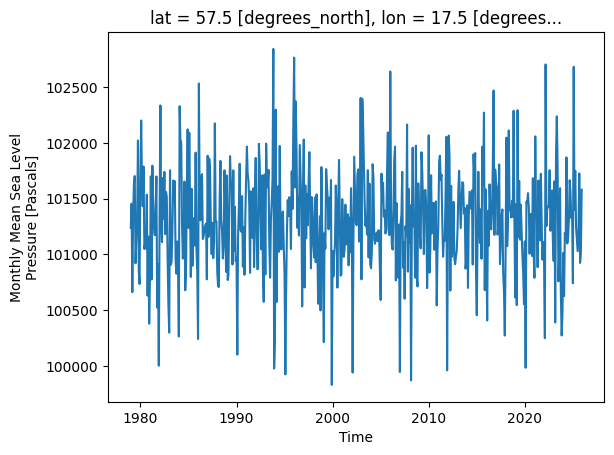

In [19]:
stockholm.plot()
plt.savefig('stockholm-full.pdf')

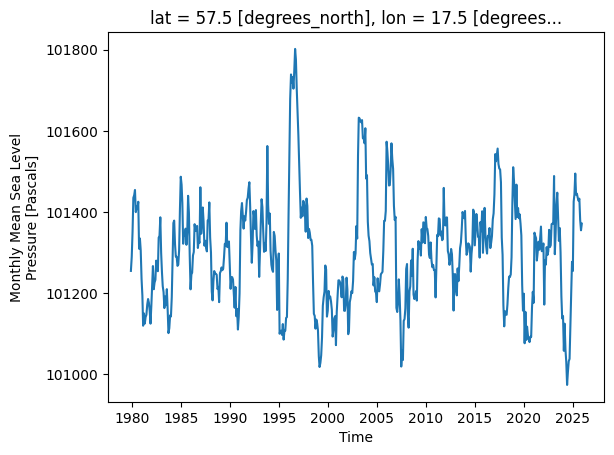

In [20]:
stockholm.rolling(time=12).mean().plot()
plt.savefig('stockholm-sliding12.pdf')

In [21]:
anom = stockholm - stockholm.mean(dim="time")

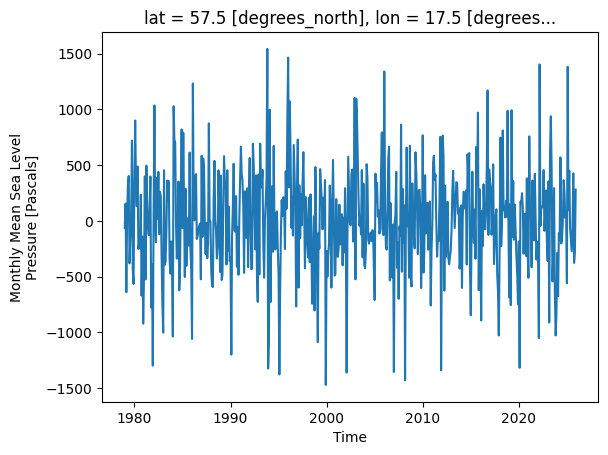

In [22]:
anom.plot()

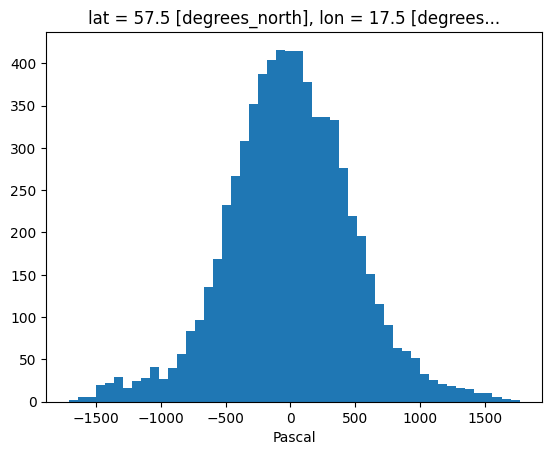

In [69]:
anom.plot.hist(bins=50)
plt.xlabel("Pascal")
plt.savefig('stockholm-hist.pdf')

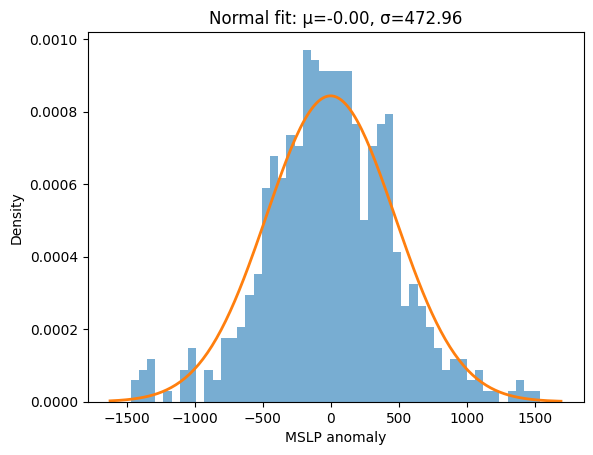

In [24]:
# Flatten and remove NaNs
data = anom.values.ravel()
data = data[~np.isnan(data)]

# Fit normal distribution
mu, sigma = norm.fit(data)

# Plot histogram
plt.hist(data, bins=50, density=True, alpha=0.6)

# Plot fitted Gaussian
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 200)
p = norm.pdf(x, mu, sigma)

plt.plot(x, p, linewidth=2)

plt.xlabel("MSLP anomaly")
plt.ylabel("Density")
plt.title(f"Normal fit: μ={mu:.2f}, σ={sigma:.2f}")
plt.savefig('stockholm-norm.pdf')
plt.show()

In [25]:
from scipy.stats import moment
from scipy.stats import skew
from scipy.stats import kurtosis

skew(data)

np.float32(-0.045959137)

In [26]:
kurtosis(data, fisher=False)

np.float32(3.763235)

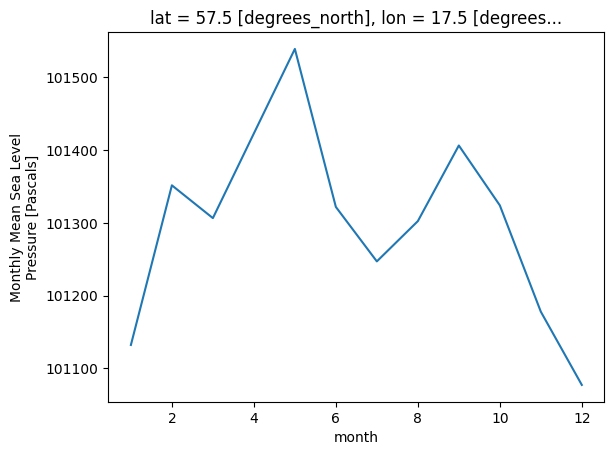

In [27]:

year = stockholm.groupby("time.month").mean("time")


year.plot()

plt.savefig('stockholm-year.pdf')

In [61]:
max_lag = 12  # months

acf = xr.DataArray(
    [xr.corr(stockholm, stockholm.shift(time=lag), dim="time")
     for lag in range(max_lag + 1)],
    dims=["lag"],
    coords={"lag": np.arange(max_lag + 1)}
)

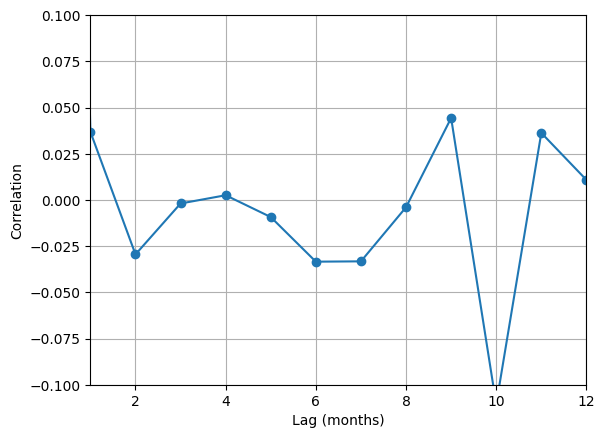

In [64]:
acf.plot(marker="o")
plt.xlabel("Lag (months)")
plt.ylabel("Correlation")
plt.xlim(1,12)
plt.ylim(-0.1,0.1)
plt.grid()

In [65]:
detrend = stockholm.groupby("time.month") - stockholm.groupby("time.month").mean("time")

acf_det = xr.DataArray(
    [xr.corr(detrend, detrend.shift(time=lag), dim="time")
     for lag in range(max_lag + 1)],
    dims=["lag"],
    coords={"lag": np.arange(max_lag + 1)}
)



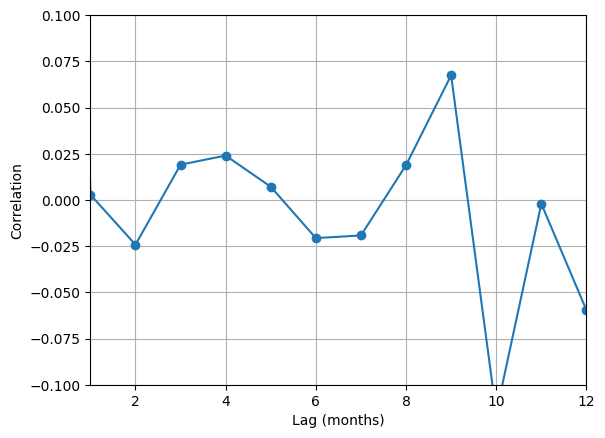

In [67]:
acf_det.plot(marker="o")
plt.xlabel("Lag (months)")
plt.ylabel("Correlation")
plt.xlim(1,12)
plt.ylim(-0.1,0.1)
plt.grid()